# Links to Github and Streamlit

Github: https://github.com/mohamadalkawadri/mohamadalkawadri-IND320-project branch name is assignment-2

Streamlit: https://mohamadalkawadri-ind320-project-assign.streamlit.app/

# AI usage

I used AI to help me fix various errors specially in connecting to
cassandra using spark and connecting to mongo DB.

I also used in plotting where it helped me make the plots, lastly I used AI to make the fourth
page, overall AI was really useful but it made small mistakes which I corrected it.

# Log describing the compulsory work

My experince with jupyter notebook was very good for trying to get the data and trying differnt code to get it working. It also made things easier when I hade to connect to cassandra and Mongo DB as I also was able to try many different values to see what worked in the end.

When connecting to Cassandra I kept getting an error that Cassandra library was not found in Spark, it took me a lot of time to find out in the end a restart fixed the problem not sure why...

For me working with MongoDB felt eaiser than working with Cassandra, especially connecting to MongoDB was easier, worked from the first try. Meanwhile Cassandra took me multiple iterations.

The API was also easy to work with, did not take many attempts before I found out how to get the data, however a limitation in the API that you can get data for maximum one month at a time which made me make a Python loop to get all months, this made the code somewhat more complicated.

In Cassandra after I got the data I thought I would use the startTime as the primary column however for some reason it only stored the data for the second month of the year, not sure why, but when I change the primary column it worked well.

For plots I got help from AI, which was useful, the same applies to the Streamlit page, I only had to do minor modifications after the AI which were small fixes, and checking all the code and making the code consistent with the Notebook.

Depolying the application to Streamlit was straight forward and I didn't need any documentations to do it. The only hiccups were missing packages and path issues, fixed by updating the requirements.txt file and using relative paths with the CSV placed next to Home.py file. Additionally I had to update the requirements.txt file. However one limitation in deploying the Streamlit app is that I could not change the branch, so I had to create a new app to get it working correctly.

In [1]:
import requests, pandas as pd
import requests, calendar
from datetime import date

all_data = []

for m in range(1, 13):
    first = date(2021, m, 1).strftime("%Y-%m-%d")
    last_day = calendar.monthrange(2021, m)[1]
    last = date(2021, m, last_day).strftime("%Y-%m-%d")

    print(f"Fetching {first} to {last}")

    resp = requests.get(f"https://api.elhub.no/energy-data/v0/price-areas?dataset=PRODUCTION_PER_GROUP_MBA_HOUR&startDate={first}&endDate={last}",)
    resp.raise_for_status()
    raw = resp.json()

    for data in raw["data"]:
        all_data = all_data + data["attributes"]["productionPerGroupMbaHour"]

df = pd.DataFrame(all_data)
df.columns = df.columns.str.lower() # Making all columns lowercase for cassandra compatibility
df.head()

Fetching 2021-01-01 to 2021-01-31
Fetching 2021-02-01 to 2021-02-28
Fetching 2021-03-01 to 2021-03-31
Fetching 2021-04-01 to 2021-04-30
Fetching 2021-05-01 to 2021-05-31
Fetching 2021-06-01 to 2021-06-30
Fetching 2021-07-01 to 2021-07-31
Fetching 2021-08-01 to 2021-08-31
Fetching 2021-09-01 to 2021-09-30
Fetching 2021-10-01 to 2021-10-31
Fetching 2021-11-01 to 2021-11-30
Fetching 2021-12-01 to 2021-12-31


,endtime,lastupdatedtime,pricearea,productiongroup,quantitykwh,starttime
0,2021-01-01T01:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2507716.8,2021-01-01T00:00:00+01:00
1,2021-01-01T02:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2494728.0,2021-01-01T01:00:00+01:00
2,2021-01-01T03:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2486777.5,2021-01-01T02:00:00+01:00
3,2021-01-01T04:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2461176.0,2021-01-01T03:00:00+01:00
4,2021-01-01T05:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2466969.2,2021-01-01T04:00:00+01:00


In [2]:
from cassandra.cluster import Cluster
cluster = Cluster(['localhost'], port=9042)
session = cluster.connect()
session.execute("CREATE KEYSPACE IF NOT EXISTS assignment2 WITH REPLICATION = { 'class' : 'SimpleStrategy', 'replication_factor' : 1 };")

In [3]:
session.execute(
    """
    DROP TABLE IF EXISTS assignment2.elhub_production_per_group_hour;
    """
)
session.execute(
    """
    CREATE TABLE IF NOT EXISTS assignment2.elhub_production_per_group_hour (
        priceArea        text,
        productionGroup  text,
        startTime        timestamp,
        endTime          timestamp,
        lastUpdatedTime  timestamp,
        quantityKwh      double,
        PRIMARY KEY ((priceArea, productionGroup), startTime)
        );
    """
)

In [4]:
import os
os.environ["PYSPARK_SUBMIT_ARGS"] = "--packages com.datastax.spark:spark-cassandra-connector_2.12:3.5.1 pyspark-shell"

In [5]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("SparkCassandraApp")
    .config('spark.jars.packages', 'com.datastax.spark:spark-cassandra-connector_2.12:3.5.1').\
    config('spark.cassandra.connection.host', 'localhost').\
    config('spark.sql.extensions', 'com.datastax.spark.connector.CassandraSparkExtensions').\
    config('spark.sql.catalog.mycatalog', 'com.datastax.spark.connector.datasource.CassandraCatalog').\
    config('spark.cassandra.connection.port', '9042').getOrCreate()
)

sdf = spark.createDataFrame(df)

(
    sdf
    .write
    .format("org.apache.spark.sql.cassandra")
    .options(keyspace="assignment2", table="elhub_production_per_group_hour")
    .mode("append")
    .save()
)

:: loading settings :: url = jar:file:/Users/mohamad/anaconda3/envs/D2D_env/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/mohamad/.ivy2/cache
The jars for the packages stored in: /Users/mohamad/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-bc43153d-69d7-4bc7-bf31-766e562a4e63;1.0
	confs: [default]
	found com.datastax.spark#spark-cassandra-connector_2.12;3.5.1 in central
	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.1 in central
	found org.scala-lang.modules#scala-collection-compat_2.12;2.11.0 in central
	found org.apache.cassandra#java-driver-core-shaded;4.18.1 in central
	found com.datastax.oss#native-protocol;1.5.1 in central
	found com.datastax.oss#java-driver-shaded-guava;25.1-jre-graal-sub-1 in central
	found com.typesafe#config;1.4.1 in central
	found org.slf4j#slf4j-api;1.7.26 in central
	found io.dropwizard.metrics#metrics-core;4.1.18 in central
	found org.hdrhistogram#HdrHistogram;2.1.12 in central
	found org.reactivestreams#reactive-streams

In [6]:
sdf_sel = (
    spark.read
    .format("org.apache.spark.sql.cassandra")
    .options(keyspace="assignment2", table="elhub_production_per_group_hour")
    .load()
    .select("priceArea", "productionGroup", "startTime", "quantityKwh")
)
sdf_sel.show(12)

+---------+---------------+-------------------+-----------+
|priceArea|productionGroup|          startTime|quantityKwh|
+---------+---------------+-------------------+-----------+
|      NO4|           wind|2021-01-01 00:00:00|   381065.0|
|      NO4|           wind|2021-01-01 01:00:00|   369910.0|
|      NO4|           wind|2021-01-01 02:00:00|   350466.0|
|      NO4|           wind|2021-01-01 03:00:00|   363722.0|
|      NO4|           wind|2021-01-01 04:00:00|   364319.0|
|      NO4|           wind|2021-01-01 05:00:00|   370376.0|
|      NO4|           wind|2021-01-01 06:00:00|   346964.0|
|      NO4|           wind|2021-01-01 07:00:00|   345921.0|
|      NO4|           wind|2021-01-01 08:00:00|   345898.0|
|      NO4|           wind|2021-01-01 09:00:00|   319965.0|
|      NO4|           wind|2021-01-01 10:00:00|   254437.0|
|      NO4|           wind|2021-01-01 11:00:00|   161516.0|
+---------+---------------+-------------------+-----------+
only showing top 12 rows



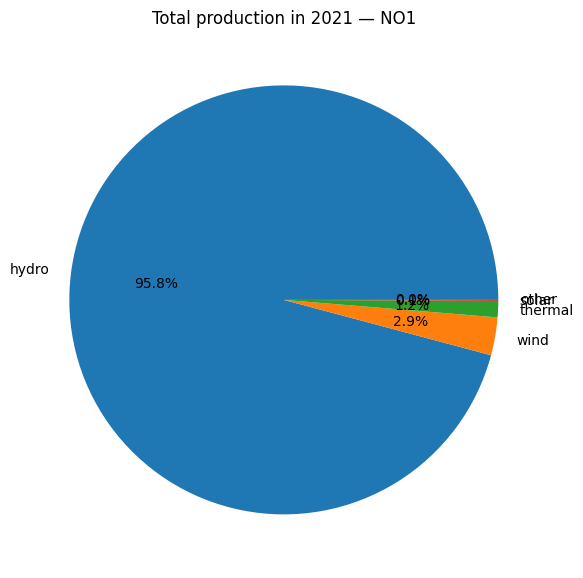

In [7]:
import matplotlib.pyplot as plt

area = "NO1"
pdf = sdf_sel.filter(sdf_sel.priceArea == area).toPandas()
totals = pdf.groupby("productionGroup")["quantityKwh"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))
totals.plot(kind="pie", autopct="%.1f%%", ylabel="", title=f"Total production in 2021 — {area}")
plt.tight_layout(); plt.show()


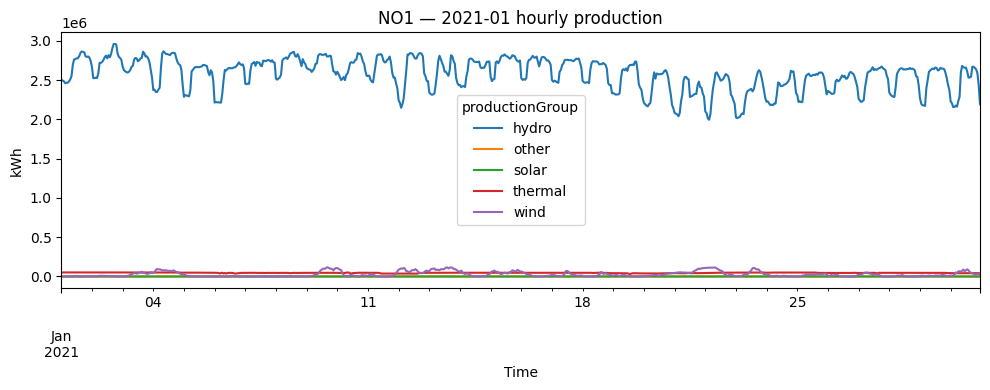

In [8]:
first_month = "2021-01"
mask = (pdf["startTime"].dt.to_period("M") == pd.Period(first_month))
m1 = pdf.loc[mask].copy()

pivot = m1.pivot_table(index="startTime", columns="productionGroup", values="quantityKwh", aggfunc="sum")
ax = pivot.plot(figsize=(10,4), title=f"{area} — {first_month} hourly production")
ax.set_xlabel("Time"); ax.set_ylabel("kWh"); plt.tight_layout(); plt.show()

In [9]:
from pymongo.mongo_client import MongoClient

uri = ("mongodb+srv://{}:{}@mohamadalkawadri.4kurdej.mongodb.net/?retryWrites=true&w=majority&appName=mohamadalkawadri")
USR, PWD = open('./secrets.txt').read().splitlines()

client = MongoClient(uri.format(USR, PWD))

# Selecting a database and a collection.
database = client['assignment2']
collection = database['elhub']

25/10/20 19:44:16 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [10]:
collection.insert_many(sdf_sel.toPandas().to_dict("records"))

InsertManyResult([ObjectId('68f674f4aad8a816c752df76'), ObjectId('68f674f4aad8a816c752df77'), ObjectId('68f674f4aad8a816c752df78'), ObjectId('68f674f4aad8a816c752df79'), ObjectId('68f674f4aad8a816c752df7a'), ObjectId('68f674f4aad8a816c752df7b'), ObjectId('68f674f4aad8a816c752df7c'), ObjectId('68f674f4aad8a816c752df7d'), ObjectId('68f674f4aad8a816c752df7e'), ObjectId('68f674f4aad8a816c752df7f'), ObjectId('68f674f4aad8a816c752df80'), ObjectId('68f674f4aad8a816c752df81'), ObjectId('68f674f4aad8a816c752df82'), ObjectId('68f674f4aad8a816c752df83'), ObjectId('68f674f4aad8a816c752df84'), ObjectId('68f674f4aad8a816c752df85'), ObjectId('68f674f4aad8a816c752df86'), ObjectId('68f674f4aad8a816c752df87'), ObjectId('68f674f4aad8a816c752df88'), ObjectId('68f674f4aad8a816c752df89'), ObjectId('68f674f4aad8a816c752df8a'), ObjectId('68f674f4aad8a816c752df8b'), ObjectId('68f674f4aad8a816c752df8c'), ObjectId('68f674f4aad8a816c752df8d'), ObjectId('68f674f4aad8a816c752df8e'), ObjectId('68f674f4aad8a816c752df